## Limpieza, transforación y EDA - Datasets Customer Analytics Cumbres


### 1. Carga y Exploración Inicial de los Datasets

#### 1.1 Estructura general

| Dataset | Filas | Columnas |
|---|---|---|
| Clientes | 1.000 | 6 |
| Transacciones | 8.000 | 7 |
| Productos | 48 | 4 |
| Tiendas | 5 | 3 |

#### 1.2 Nulos detectados por dataset

**Clientes**

| Campo | Nulos | % sobre total |
|---|---|---|
| customer_id | 0 | 0% |
| nombre | 0 | 0% |
| email | 40 | 4% |
| ciudad | 50 | 5% |
| canal_adquisicion | 0 | 0% |
| fecha_alta | 0 | 0% |

**Transacciones**

| Campo | Nulos | % sobre total |
|---|---|---|
| transaction_id | 0 | 0% |
| customer_id | 0 | 0% |
| product_id | 0 | 0% |
| store_id | 240 | 3% |
| cantidad | 0 | 0% |
| importe | 0 | 0% |
| fecha | 0 | 0% |

**Productos**

| Campo | Nulos | % sobre total |
|---|---|---|
| product_id | 0 | 0% |
| nombre | 0 | 0% |
| categoria | 0 | 0% |
| precio_base | 0 | 0% |

**Tiendas**

| Campo | Nulos | % sobre total |
|---|---|---|
| store_id | 0 | 0% |
| nombre | 0 | 0% |
| ciudad | 0 | 0% |

#### 1.3 Validación contra suciedad intencional documentada

| Campo | Nulos esperados | Nulos reales | Validación |
|---|---|---|---|
| clientes.email | 4% (40) | 40 | ✅ |
| clientes.ciudad | 5% (50) | 50 | ✅ |
| transacciones.store_id | 3% (240) | 240 | ✅ |

> ✅ Los tres tipos de suciedad intencional documentada se generaron correctamente y coinciden con los porcentajes definidos en el diseño del dataset.

In [2]:
import pandas as pd
import numpy as np

# Cargar los 4 datasets
# Cargar los 4 datasets
clientes = pd.read_csv(r'C:\Users\marti\Desktop\Customer_analytics\data\raw\clientes.csv')
transacciones = pd.read_csv(r'C:\Users\marti\Desktop\Customer_analytics\data\raw\transacciones.csv')
productos = pd.read_csv(r'C:\Users\marti\Desktop\Customer_analytics\data\raw\productos.csv')
tiendas = pd.read_csv(r'C:\Users\marti\Desktop\Customer_analytics\data\raw\tiendas.csv')

# Exploración inicial
for nombre, df in [('CLIENTES', clientes), ('TRANSACCIONES', transacciones), 
                   ('PRODUCTOS', productos), ('TIENDAS', tiendas)]:
    print(f"\n{'='*40}")
    print(f"📂 {nombre}")
    print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
    print(f"Nulos:\n{df.isnull().sum()}")


📂 CLIENTES
Filas: 1000 | Columnas: 6
Nulos:
customer_id           0
nombre                0
email                40
ciudad               50
canal_adquisicion     0
fecha_alta            0
dtype: int64

📂 TRANSACCIONES
Filas: 8000 | Columnas: 7
Nulos:
transaction_id      0
customer_id         0
product_id          0
store_id          240
cantidad            0
importe             0
fecha               0
dtype: int64

📂 PRODUCTOS
Filas: 48 | Columnas: 4
Nulos:
product_id     0
nombre         0
categoria      0
precio_base    0
dtype: int64

📂 TIENDAS
Filas: 5 | Columnas: 3
Nulos:
store_id    0
nombre      0
ciudad      0
dtype: int64


### 2. Análisis exploratorio y limpieza de nulos en cada dataset

#### Tratamiento de valores nulos — dataset clientes

**Contexto:** antes de cualquier imputación o eliminación, se realizó un análisis
exploratorio para determinar si los nulos tenían un origen sistémico o eran ruido aleatorio.

##### Metodología aplicada

Se analizaron 3 dimensiones de nulidad sobre las columnas `email` (4%) y `ciudad` (5%):

- **Solapamiento:** verificar si los mismos clientes concentraban ambos nulos
- **Canal de adquisición:** detectar si algún canal fallaba sistemáticamente en la captura
- **Temporalidad:** identificar períodos con anomalías en la calidad del dato

##### Hallazgos

- Solo 1 cliente de 1.000 presentó ambos campos nulos simultáneamente
- La tasa de nulos por canal oscila entre 2.8% y 6.1% sin outliers significativos
- No se identificó ningún período con concentración anómala de nulos (ene 2023 – dic 2025)

##### Decisión y justificación

Se decidió **conservar los nulos sin imputación ni eliminación de filas**, por dos razones:

1. Ninguna de las dos columnas participa en las preguntas analíticas del proyecto
(segmentación RFM, LTV, canal de venta, categoría de producto, estacionalidad)
2. El análisis confirmó que los nulos son aleatorios, independientes entre sí
y sin patrón de origen — no hay problema sistémico que corregir

Eliminar las filas habría significado descartar información válida de 89 clientes
(transacciones, canal, fecha de alta) para resolver un problema inexistente.

##### 2.1.1 Patrones de nulidad -> solapamiento : ¿ los mismos clientes tienen ambos nulos?

In [8]:
# Cambiar df por clientes
null_email  = clientes['email'].isna()
null_ciudad = clientes['ciudad'].isna()

solo_email  = null_email  & ~null_ciudad
solo_ciudad = ~null_email & null_ciudad
ambos       = null_email  & null_ciudad

print(f"Solo email nulo:   {solo_email.sum()}")
print(f"Solo ciudad nulo:  {solo_ciudad.sum()}")
print(f"Ambos nulos:       {ambos.sum()}")
print(f"\nClientes con algún nulo: {(null_email | null_ciudad).sum()}")

Solo email nulo:   39
Solo ciudad nulo:  49
Ambos nulos:       1

Clientes con algún nulo: 89


##### 2.1.2 Patrones de nulidad -> canal — ¿los nulos se concentran en algún canal?

In [11]:
# Bloque 2 — canal
print("=== email nulo por canal ===")
print(clientes[null_email]['canal_adquisicion'].value_counts())

print("\n=== ciudad nulo por canal ===")
print(clientes[null_ciudad]['canal_adquisicion'].value_counts())

print("\n=== % de nulos por canal ===")
tasa = clientes.groupby('canal_adquisicion').agg(
    total=('customer_id', 'count'),
    nulo_email=('email',  lambda x: x.isna().sum()),
    nulo_ciudad=('ciudad', lambda x: x.isna().sum())
)
tasa['pct_email']  = (tasa['nulo_email']  / tasa['total'] * 100).round(1)
tasa['pct_ciudad'] = (tasa['nulo_ciudad'] / tasa['total'] * 100).round(1)
print(tasa[['total','pct_email','pct_ciudad']])

=== email nulo por canal ===
canal_adquisicion
paid        13
organico    11
tienda       9
referral     7
Name: count, dtype: int64

=== ciudad nulo por canal ===
canal_adquisicion
referral    15
organico    14
paid        12
tienda       9
Name: count, dtype: int64

=== % de nulos por canal ===
                   total  pct_email  pct_ciudad
canal_adquisicion                              
organico             229        4.8         6.1
paid                 233        5.6         5.2
referral             249        2.8         6.0
tienda               289        3.1         3.1


##### 2.1.3 Patrones de nulidad -> temporalidad — ¿los nulos aparecen en un período concreto?

In [12]:
# Bloque 3 — temporalidad
clientes['fecha_alta'] = pd.to_datetime(clientes['fecha_alta'])
clientes['anio_mes']   = clientes['fecha_alta'].dt.to_period('M')

evolucion = clientes.groupby('anio_mes').agg(
    total=('customer_id', 'count'),
    nulo_email=('email',  lambda x: x.isna().sum()),
    nulo_ciudad=('ciudad', lambda x: x.isna().sum())
)
evolucion['pct_email']  = (evolucion['nulo_email']  / evolucion['total'] * 100).round(1)
evolucion['pct_ciudad'] = (evolucion['nulo_ciudad'] / evolucion['total'] * 100).round(1)

print(evolucion[evolucion['nulo_email'] + evolucion['nulo_ciudad'] > 0])

          total  nulo_email  nulo_ciudad  pct_email  pct_ciudad
anio_mes                                                       
2023-01      28           1            3        3.6        10.7
2023-02      22           2            3        9.1        13.6
2023-03      27           2            0        7.4         0.0
2023-04      34           0            2        0.0         5.9
2023-05      35           0            3        0.0         8.6
2023-06      34           2            1        5.9         2.9
2023-07      31           3            0        9.7         0.0
2023-08      28           0            3        0.0        10.7
2023-09      16           1            1        6.2         6.2
2023-10      29           0            3        0.0        10.3
2023-11      32           1            4        3.1        12.5
2023-12      32           2            2        6.2         6.2
2024-01      34           1            1        2.9         2.9
2024-02      22           0            1

#### 2.2 Tratamiento de valores nulos - dataset transacciones

**Campo afectado:** `store_id` — 240 nulos (3% de 8.000 transacciones)

#### Análisis previo a la decisión

Se analizaron 3 dimensiones antes de imputar:

- **Distribución temporal:** los nulos aparecen de forma uniforme entre enero 2023
y diciembre 2025, entre 3 y 11 registros por mes, sin concentración en ningún período
- **Ticket medio:** 220.35 — coherente con el rango del resto de tiendas (228–240)
y con T05 · Cumbres Web (236.30) específicamente
- **Catálogo de tiendas:** existe explícitamente una tienda `T05 · Cumbres Web · Online`,
lo que indica que el canal web está contemplado en el sistema

#### Hipótesis

Las transacciones con `store_id` nulo corresponden a ventas web que no registraron
correctamente su identificador de tienda. La distribución uniforme a lo largo de 3 años
descarta un bug puntual y apunta a un problema crónico de configuración en el origen.

#### Limitaciones

> **Nota:** esta es una asunción basada en evidencia circunstancial, no en validación
> externa. En un entorno productivo se requeriría confirmación del equipo técnico
> o cruce con logs del sistema antes de imputar.
> En este proyecto los datos son simulados, por lo que se acepta la hipótesis
> y se documenta explícitamente.

####  Decisión 

Se imputan los 240 nulos con el valor `T05`, ya que `store_id` participa directamente
en la pregunta operativa 4 — *¿qué canal de venta genera mayor ticket medio?* —
y la evidencia disponible respalda que corresponden a ventas online.
```python
transacciones['store_id'] = transacciones['store_id'].fillna('T05')
```

---

*Herramientas: Python · pandas*

In [4]:
print(tiendas)

  store_id             nombre     ciudad
0      T01     Cumbres Madrid     Madrid
1      T02  Cumbres Barcelona  Barcelona
2      T03   Cumbres Valencia   Valencia
3      T04    Cumbres Sevilla    Sevilla
4      T05        Cumbres Web     Online


In [3]:
# ¿Cuántas transacciones tiene T05 vs nulos?
print(transacciones['store_id'].value_counts(dropna=False))

store_id
T04    1622
T05    1591
T02    1531
T01    1525
T03    1491
NaN     240
Name: count, dtype: int64


In [14]:
comparacion = transacciones.groupby(
    transacciones['store_id'].fillna('NULO')
)['importe'].agg(['mean','count']).round(2)
print(comparacion)

            mean  count
store_id               
NULO      220.35    240
T01       228.26   1525
T02       230.03   1531
T03       240.14   1491
T04       233.91   1622
T05       236.30   1591


In [15]:
# ¿Los nulos se concentran en algún período concreto?
transacciones['fecha'] = pd.to_datetime(transacciones['fecha'])
transacciones['anio_mes'] = transacciones['fecha'].dt.to_period('M')

temporal = transacciones[transacciones['store_id'].isna()].groupby('anio_mes').size()
print(temporal)

anio_mes
2023-01    10
2023-02     4
2023-03     9
2023-04     7
2023-05    11
2023-06     4
2023-07     5
2023-08     5
2023-09     3
2023-10     6
2023-11     6
2023-12     5
2024-01     3
2024-02     6
2024-03     7
2024-04    10
2024-05     7
2024-06     6
2024-07     4
2024-08     9
2024-09     6
2024-10     8
2024-11     9
2024-12     8
2025-01     7
2025-02     5
2025-03     9
2025-04     9
2025-05     6
2025-06     7
2025-07     6
2025-08     7
2025-09     8
2025-10     5
2025-11     5
2025-12     8
Freq: M, dtype: int64


In [6]:
## Se agregaron los 240 nulos en la columna 'T05'
transacciones['store_id'] = transacciones['store_id'].fillna('T05')

In [5]:
print(transacciones['store_id'].value_counts(dropna=False))

store_id
T05    1831
T04    1622
T02    1531
T01    1525
T03    1491
Name: count, dtype: int64


### 3. Estadística descriptiva

##### 3.1 Variables númericas
En importe: 
- Existen valores negativos. El mínimo es -2378.40, lo cual es una señal importante. En un contexto de ventas los importes negativos típicamente representan devoluciones o abonos, no errores. Pero hay que verificar cuántos son y si tienen algún patrón.
- La media y la mediana están separadas. Media 233 vs mediana 210 — hay sesgo hacia la derecha, lo que sugiere algunos importes altos que tiran de la media. El máximo de 3198 vs el percentil 75 de 308 confirma que hay transacciones de ticket muy alto.
  
En cantidad: se ve limpia
- Rango de 1 a 3, sin valores imposibles. Sin nada que investigar aquí.

In [7]:
# Estadísticas descriptivas — variables numéricas
print(transacciones[['importe', 'cantidad']].describe().round(2))

       importe  cantidad
count  8000.00   8000.00
mean    233.32      1.39
std     271.86      0.63
min   -2378.40      1.00
25%     111.36      1.00
50%     210.32      1.00
75%     308.83      2.00
max    3198.16      3.00


#### Tratamiento de valores negativos — campo `importe`

**Campo afectado:** `importe` — 80 registros negativos (1% de 8.000 transacciones)

##### Análisis previo a la decisión

Se identificaron 80 transacciones con importe negativo, con una media de -257.53
y un mínimo de -2378.40. Antes de decidir su tratamiento se verificó su distribución
por tienda:

| Tienda | Negativos | % sobre su total |
|---|---|---|
| T01 · Madrid | 18 | 1.18% |
| T02 · Barcelona | 15 | 0.98% |
| T03 · Valencia | 18 | 1.21% |
| T04 · Sevilla | 15 | 0.92% |
| T05 · Web | 14 | 0.76% |


###### Interpretación — transacciones negativas (devoluciones)

Se registraron 80 devoluciones, representando el 1% del total de transacciones.
Los importes devueltos oscilan entre 21 y 2.378, con un promedio de 257.

La dispersión es alta — la desviación estándar (356) supera a la media (257) —
lo que indica que las devoluciones no son homogéneas: conviven devoluciones de
tickets pequeños con devoluciones de alto valor.

La distribución por tienda es uniforme, entre 0.76% y 1.21% en todos los canales,
lo que confirma que se trata de un comportamiento natural del negocio y no de
un problema localizado en ningún canal específico.

**Decisión:** se conservan los 80 registros negativos sin modificación.


###### Conclusión del análisis

La distribución es uniforme entre todas las tiendas, sin concentración en ningún
canal ni tienda específica. El volumen (1%) es coherente con una tasa de devolución
normal en retail. No se identificaron patrones que sugieran errores de registro.


###### Decisión

Se conservan los registros negativos sin modificación, ya que representan
devoluciones legítimas dentro del ciclo de venta. Excluirlos daría una imagen
artificialmente positiva del valor del cliente — se estaría midiendo lo que compra,
no lo que realmente aporta al negocio.

Conservar los negativos permite que el LTV refleje el comportamiento completo
del cliente: compras menos devoluciones. Esto es especialmente relevante para
la pregunta operativa 3 — *¿cuál es el LTV medio por segmento RFM?*

---

*Herramientas: Python · pandas*

In [9]:
## Se observa qué sucede con los valores negativos: 

negativos = transacciones[transacciones['importe'] < 0]
print(f"Total negativos: {len(negativos)}")
print(f"% sobre total: {round(len(negativos)/len(transacciones)*100, 2)}%")
print(negativos[['importe', 'store_id', 'cantidad']].describe().round(2))

Total negativos: 80
% sobre total: 1.0%
       importe  cantidad
count    80.00     80.00
mean   -257.53      1.39
std     356.52      0.58
min   -2378.40      1.00
25%    -293.07      1.00
50%    -201.42      1.00
75%    -117.29      2.00
max     -21.04      3.00


In [10]:
print(negativos['store_id'].value_counts())
print()
print(round(negativos['store_id'].value_counts() / 
      transacciones['store_id'].value_counts() * 100, 2))

store_id
T01    18
T03    18
T04    15
T02    15
T05    14
Name: count, dtype: int64

store_id
T01    1.18
T02    0.98
T03    1.21
T04    0.92
T05    0.76
Name: count, dtype: float64


#### 3.2 Tratamiento de valores positivos - campo `importe`

**Campo afectado:** `importe` — 80 registros por encima del percentil 99 (1.583)

### Análisis previo a la decisión

La distribución por percentiles mostró una progresión gradual hasta el percentil 95
(387) seguida de un salto brusco al percentil 99 (1.583) y al máximo (3.198).
Se analizaron los 80 registros afectados:

| Métrica | Valor |
|---|---|
| Media | 2.446 |
| Desviación estándar | 476 |
| Mínimo | 1.587 |
| Máximo | 3.198 |

La distribución por tienda resultó uniforme, entre 13 y 21 registros por canal,
con T05 · Web levemente por encima, lo cual es coherente con un canal sin
fricción geográfica que puede atraer tickets más altos.

### Conclusión del análisis

El campo `cantidad` de estos registros se mantiene en el rango 1-3, idéntico
al resto del dataset. No hay señal de error de registro — son transacciones
de alto valor legítimas, posiblemente asociadas a categorías de producto
de precio elevado.

### Decisión

Se conservan los 80 registros sin modificación. Excluirlos distorsionaría
el LTV real de los clientes de alto valor, que son precisamente los más
relevantes para la segmentación RFM y la pregunta operativa 3
— *¿cuál es el LTV medio por segmento RFM?*

---

*Herramientas: Python · pandas*

In [11]:
print(transacciones[['importe']].quantile([0.90, 0.95, 0.99, 1.0]).round(2))

      importe
0.90   367.50
0.95   387.93
0.99  1583.40
1.00  3198.16


In [13]:
 ## Verifar cuántos registros hay por encima del percentil 99 

p99 = transacciones['importe'].quantile(0.99)
outliers_altos = transacciones[transacciones['importe'] > p99]

print(f"Total outliers altos: {len(outliers_altos)}")
print(f"Importe mínimo: {outliers_altos['importe'].min().round(2)}")
print(f"Importe máximo: {outliers_altos['importe'].max().round(2)}")
print()
print(outliers_altos['store_id'].value_counts())

Total outliers altos: 80
Importe mínimo: 1587.52
Importe máximo: 3198.16

store_id
T05    21
T04    19
T03    14
T01    13
T02    13
Name: count, dtype: int64


In [14]:
print(outliers_altos[['importe', 'cantidad']].describe().round(2))

       importe  cantidad
count    80.00     80.00
mean   2446.19      1.42
std     476.47      0.65
min    1587.52      1.00
25%    2059.46      1.00
50%    2367.04      1.00
75%    2894.48      2.00
max    3198.16      3.00


#### 4. Verificar consistencia entre tablas

##### Consistencia entre tablas — integridad referencial

Se verificó que todos los identificadores presentes en `transacciones` existen
en sus tablas de referencia correspondientes.

##### Conclusión

La integridad referencial está garantizada. Todos los joins entre `transacciones`
y las tablas `clientes`, `productos` y `tiendas` devolverán resultados completos
sin pérdida de registros.


In [15]:
# customer_id
clientes_en_trans = set(transacciones['customer_id'].unique())
clientes_en_tabla = set(clientes['customer_id'].unique())
inconsistentes_clientes = clientes_en_trans - clientes_en_tabla

# product_id
productos_en_trans = set(transacciones['product_id'].unique())
productos_en_tabla = set(productos['product_id'].unique())
inconsistentes_productos = productos_en_trans - productos_en_tabla

# store_id
tiendas_en_trans = set(transacciones['store_id'].unique())
tiendas_en_tabla = set(tiendas['store_id'].unique())
inconsistentes_tiendas = tiendas_en_trans - tiendas_en_tabla

print(f"customer_id inconsistentes: {len(inconsistentes_clientes)}")
print(f"product_id inconsistentes:  {len(inconsistentes_productos)}")
print(f"store_id inconsistentes:    {len(inconsistentes_tiendas)}")

customer_id inconsistentes: 0
product_id inconsistentes:  0
store_id inconsistentes:    0


#### 5. Distribución temporal

##### Período analizado
Enero 2023 – diciembre 2025 (36 meses continuos, sin gaps)

##### Hallazgos

**Volumen de transacciones**
Oscila entre 178 y 255 transacciones por mes, manteniéndose estable alrededor
de la media durante todo el período. No se identificaron meses sin actividad
ni picos anómalos significativos.

**Importe total mensual**
Se mueve entre 43.000 y 59.000, consistente con el volumen estable de
transacciones. Sin tendencia creciente ni decreciente a lo largo de los 3 años.

**Ticket medio**
Oscila entre 191 y 279, con variabilidad natural mes a mes pero sin patrón
estacional ni tendencia reconocible.

##### Conclusión

El dataset es temporalmente limpio y consistente. La ausencia de estacionalidad
y tendencia es coherente con el origen sintético de los datos y no afecta
la validez del análisis posterior.



In [16]:
transacciones['fecha'] = pd.to_datetime(transacciones['fecha'])
transacciones['anio_mes'] = transacciones['fecha'].dt.to_period('M')

temporal = transacciones.groupby('anio_mes').agg(
    transacciones=('transaction_id', 'count'),
    importe_total=('importe', 'sum'),
    ticket_medio=('importe', 'mean')
).round(2)

print(temporal)

          transacciones  importe_total  ticket_medio
anio_mes                                            
2023-01             230       50586.52        219.94
2023-02             217       48383.09        222.96
2023-03             234       50659.52        216.49
2023-04             206       50523.40        245.26
2023-05             212       50107.78        236.36
2023-06             215       50897.90        236.73
2023-07             222       51966.91        234.09
2023-08             233       44656.17        191.66
2023-09             205       48385.60        236.03
2023-10             255       56932.01        223.26
2023-11             219       51121.99        233.43
2023-12             213       55118.68        258.77
2024-01             197       54976.22        279.07
2024-02             225       52072.96        231.44
2024-03             228       59756.95        262.09
2024-04             227       50511.74        222.52
2024-05             235       50529.97        

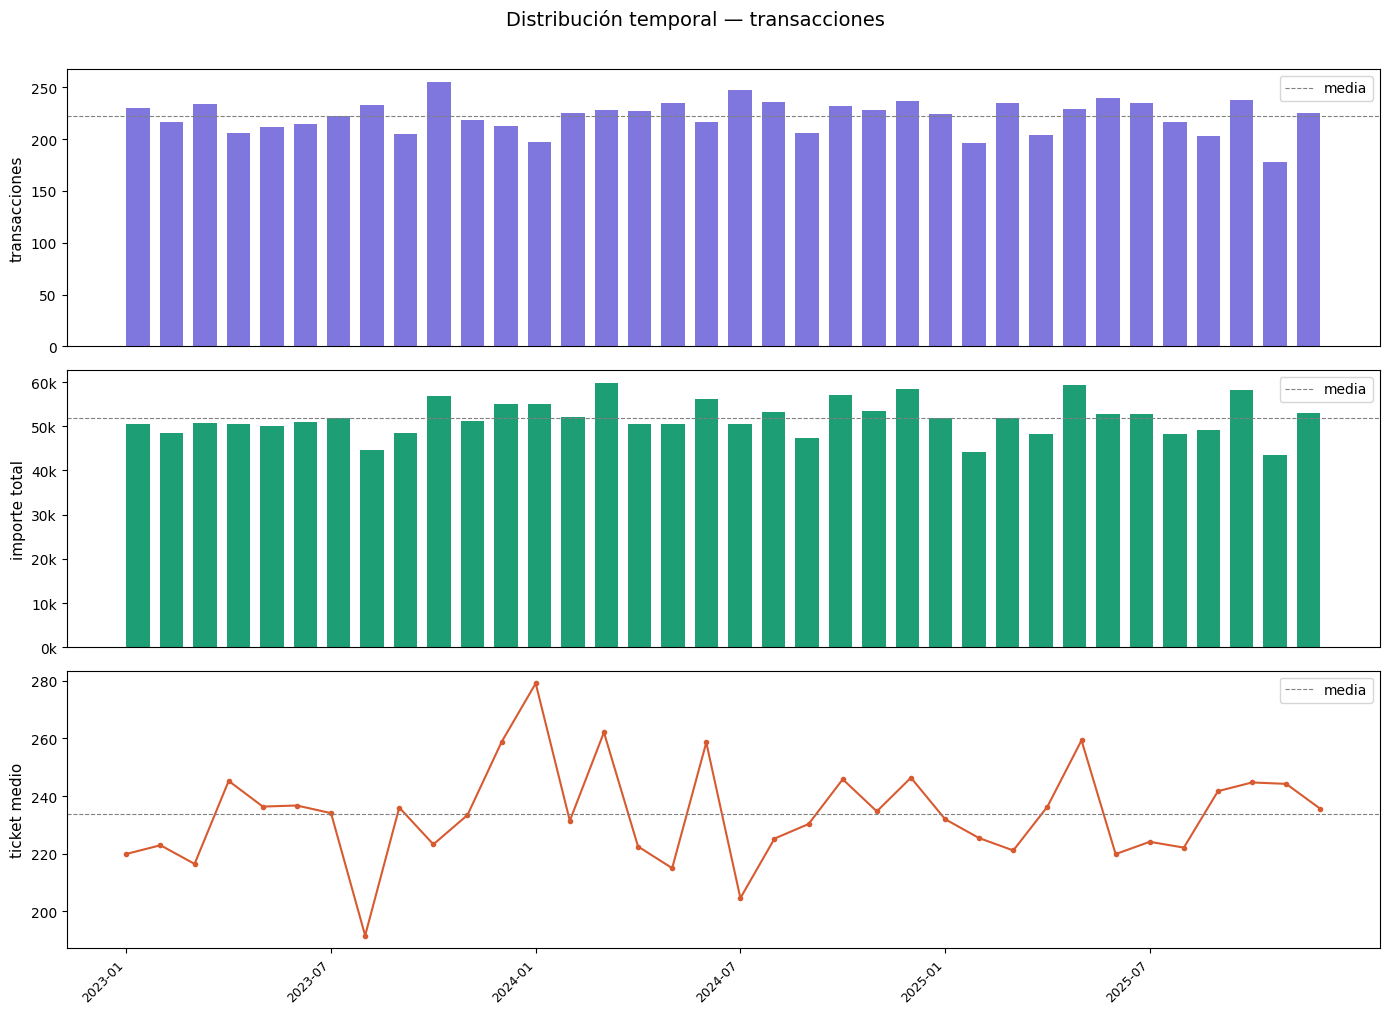

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Distribución temporal — transacciones', fontsize=14, fontweight='500', y=1.01)

periodos = temporal.index.astype(str)
x = range(len(periodos))

# Transacciones por mes
axes[0].bar(x, temporal['transacciones'], color='#7F77DD', width=0.7)
axes[0].set_ylabel('transacciones', fontsize=11)
axes[0].set_xticks([])
axes[0].axhline(temporal['transacciones'].mean(), color='gray', linestyle='--', linewidth=0.8, label='media')
axes[0].legend(fontsize=10)

# Importe total por mes
axes[1].bar(x, temporal['importe_total'], color='#1D9E75', width=0.7)
axes[1].set_ylabel('importe total', fontsize=11)
axes[1].set_xticks([])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{int(val/1000)}k'))
axes[1].axhline(temporal['importe_total'].mean(), color='gray', linestyle='--', linewidth=0.8, label='media')
axes[1].legend(fontsize=10)

# Ticket medio por mes
axes[2].plot(x, temporal['ticket_medio'], color='#D85A30', linewidth=1.5, marker='o', markersize=3)
axes[2].set_ylabel('ticket medio', fontsize=11)
axes[2].set_xticks(list(x)[::6])
axes[2].set_xticklabels(periodos[::6], rotation=45, ha='right', fontsize=9)
axes[2].axhline(temporal['ticket_medio'].mean(), color='gray', linestyle='--', linewidth=0.8, label='media')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

#### 6. Distribución variables categóricas: dataset transacciones

##### Por tienda

| Tienda | Transacciones | % | Ticket medio |
|---|---|---|---|
| T01 · Madrid | 1.525 | 19.1% | 228 |
| T02 · Barcelona | 1.531 | 19.1% | 230 |
| T03 · Valencia | 1.491 | 18.6% | 240 |
| T04 · Sevilla | 1.622 | 20.3% | 234 |
| T05 · Web | 1.831 | 22.9% | 234 |

T05 · Web es el canal más activo con el 22.9% de las transacciones y el importe
total más alto (428k), coherente con un canal sin restricción geográfica.
La distribución entre tiendas físicas es uniforme, sin ninguna tienda dominante.

##### Por categoría

| Categoría | Transacciones | % | Ticket medio |
|---|---|---|---|
| Ciclismo | 2.036 | 25.4% | 226 |
| Montaña | 2.022 | 25.3% | 237 |
| Padel | 2.013 | 25.2% | 231 |
| Running | 1.929 | 24.1% | 240 |

Las 4 categorías presentan una distribución equilibrada. Running registra el ticket
medio más alto (240) y Ciclismo el más bajo (226), aunque la diferencia es pequeña
y será analizada en detalle en la fase de preguntas operativas.

##### Por producto

Los 10 productos más frecuentes oscilan entre 2.2% y 2.5% del total de
transacciones, sin ningún producto dominante. El catálogo está balanceado
entre los 50 productos del dataset.

##### Conclusión

No se identificó ningún desbalance extremo en ninguna dimensión categórica.
La distribución es uniforme entre tiendas, categorías y productos, lo que
garantiza que el análisis posterior no estará sesgado por la concentración
en ninguna categoría específica.


In [18]:
# Distribución por tienda
print("=== transacciones por tienda ===")
tienda_dist = transacciones.groupby('store_id').agg(
    transacciones=('transaction_id', 'count'),
    importe_total=('importe', 'sum'),
    ticket_medio=('importe', 'mean')
).round(2)
tienda_dist['pct'] = (tienda_dist['transacciones'] / len(transacciones) * 100).round(1)
print(tienda_dist)

# Distribución por producto
print("\n=== transacciones por producto ===")
producto_dist = transacciones.groupby('product_id').agg(
    transacciones=('transaction_id', 'count'),
    importe_total=('importe', 'sum')
).round(2)
producto_dist['pct'] = (producto_dist['transacciones'] / len(transacciones) * 100).round(1)
print(producto_dist.sort_values('transacciones', ascending=False).head(10))

=== transacciones por tienda ===
          transacciones  importe_total  ticket_medio   pct
store_id                                                  
T01                1525      348090.84        228.26  19.1
T02                1531      352169.66        230.03  19.1
T03                1491      358048.66        240.14  18.6
T04                1622      379404.72        233.91  20.3
T05                1831      428834.86        234.21  22.9

=== transacciones por producto ===
            transacciones  importe_total  pct
product_id                                   
P037                  197       42579.15  2.5
P025                  193       39757.39  2.4
P009                  188       40596.79  2.4
P014                  183       47996.94  2.3
P017                  183       39780.73  2.3
P048                  180       44490.25  2.2
P006                  178       49976.98  2.2
P013                  178       36543.38  2.2
P032                  178       40638.05  2.2
P027        

In [19]:
# Cruzar transacciones con categoría de producto
trans_cat = transacciones.merge(
    productos[['product_id', 'categoria']], 
    on='product_id', 
    how='left'
)

print("=== transacciones por categoría ===")
cat_dist = trans_cat.groupby('categoria').agg(
    transacciones=('transaction_id', 'count'),
    importe_total=('importe', 'sum'),
    ticket_medio=('importe', 'mean')
).round(2)
cat_dist['pct'] = (cat_dist['transacciones'] / len(transacciones) * 100).round(1)
print(cat_dist.sort_values('importe_total', ascending=False))

=== transacciones por categoría ===
           transacciones  importe_total  ticket_medio   pct
categoria                                                  
Montaña             2022      478266.50        236.53  25.3
Padel               2013      465087.84        231.04  25.2
Running             1929      462723.69        239.88  24.1
Ciclismo            2036      460470.71        226.16  25.4


#### 7. Duplicados por dataset

In [ ]:
# Duplicados por dataset
for nombre, df in [('clientes', clientes), ('transacciones', transacciones),
                   ('productos', productos), ('tiendas', tiendas)]:
    duplicados = df.duplicated().sum()
    print(f"{nombre}: {duplicados} duplicados")

#### 8. Transformación de los tipos de datos en formato de lectura MySQL

In [22]:
for nombre, df in [('clientes', clientes), ('transacciones', transacciones),
                   ('productos', productos), ('tiendas', tiendas)]:
    print(f"\n=== {nombre} ===")
    print(df.dtypes)


=== clientes ===
customer_id          object
nombre               object
email                object
ciudad               object
canal_adquisicion    object
fecha_alta           object
dtype: object

=== transacciones ===
transaction_id            object
customer_id               object
product_id                object
store_id                  object
cantidad                   int64
importe                  float64
fecha             datetime64[ns]
anio_mes               period[M]
dtype: object

=== productos ===
product_id      object
nombre          object
categoria       object
precio_base    float64
dtype: object

=== tiendas ===
store_id    object
nombre      object
ciudad      object
dtype: object


In [23]:
# clientes
clientes['fecha_alta'] = pd.to_datetime(clientes['fecha_alta']).dt.strftime('%Y-%m-%d')

# transacciones
transacciones['fecha'] = transacciones['fecha'].dt.strftime('%Y-%m-%d')
transacciones = transacciones.drop(columns=['anio_mes'])

# Verificar
for nombre, df in [('clientes', clientes), ('transacciones', transacciones),
                   ('productos', productos), ('tiendas', tiendas)]:
    print(f"\n=== {nombre} ===")
    print(df.dtypes)


=== clientes ===
customer_id          object
nombre               object
email                object
ciudad               object
canal_adquisicion    object
fecha_alta           object
dtype: object

=== transacciones ===
transaction_id     object
customer_id        object
product_id         object
store_id           object
cantidad            int64
importe           float64
fecha              object
dtype: object

=== productos ===
product_id      object
nombre          object
categoria       object
precio_base    float64
dtype: object

=== tiendas ===
store_id    object
nombre      object
ciudad      object
dtype: object


#### 9. Exportación de datos CLEAN

In [26]:
import os

ruta = r'C:\Users\marti\Desktop\Customer_analytics\data\clean'

clientes.to_csv(os.path.join(ruta, 'clientes_clean.csv'), index=False, encoding='utf-8')
transacciones.to_csv(os.path.join(ruta, 'transacciones_clean.csv'), index=False, encoding='utf-8')
productos.to_csv(os.path.join(ruta, 'productos_clean.csv'), index=False, encoding='utf-8')
tiendas.to_csv(os.path.join(ruta, 'tiendas_clean.csv'), index=False, encoding='utf-8')

print("Archivos exportados correctamente")

Archivos exportados correctamente


#### 10. Estado final de los datasets — preparación para MySQL

Como resultado del EDA y las decisiones de limpieza, los 4 datasets quedaron
en las siguientes condiciones antes de ser exportados a CSV:

| Dataset | Filas | Columnas | Modificaciones aplicadas |
|---|---|---|---|
| `clientes` | 1.000 | 6 | `fecha_alta` formateada a `YYYY-MM-DD`. Nulos de `email` y `ciudad` conservados |
| `transacciones` | 8.000 | 7 | `store_id` imputado con `T05`. `fecha` formateada a `YYYY-MM-DD`. Columna auxiliar `anio_mes` eliminada |
| `productos` | 50 | 4 | Sin modificaciones |
| `tiendas` | 5 | 3 | Sin modificaciones |

Los 4 archivos fueron exportados a `data\clean` listos para `LOAD DATA` en MySQL.
